### DAHITI and Hydroweb validation

Read data → match lakes → match dates → merge and save.

All readers return WGS84 GeoDataFrames with `date`, `water_level`, and point `geometry`.
Keep lakes present in all three sources. Match each satellite observation to the
nearest in situ date within the tolerance, separately for each lake. Ties use the
earlier date; multiple satellite observations matched to one date are averaged.
Keep in situ records used by either satellite source.


In [3]:
from pathlib import Path
import geopandas as gpd
import numpy as np
import pandas as pd
import xarray as xr


#### Configuration

Run from the project root, or set `project_root` to its absolute path.


In [4]:
# project_root = Path.cwd()
# if not (project_root / 'data').is_dir():
#     project_root = next(parent for parent in project_root.parents if (parent / 'data').is_dir())

path_lakes = 'data/lake/hydrolake_hma/HydroLakes_v10_hma.gpkg'
path_stations = 'data/validation/lake_height/lake_station.gpkg'
path_insitu = 'data/validation/lake_height/lake_station_lakes_all.csv'
dir_hydroweb = 'data/water_height/hydroweb/hma_lakes'
dir_dahiti = 'data/water_height/dahiti'
# path_out_csv = project_root / 'data/water_height/merged_data.csv'
# path_out_gpkg = path_out_csv.with_suffix('.gpkg')
path_out_gpkg = 'data/water_height/merged_data.gpkg'
tolerance_days = 3


#### 1. Read data.  
Normalize dates to midnight and discard invalid dates or water levels.


In [5]:
def water_level_table(frame):
    """Standardize a table with date, water_level, and WGS84 geometry."""
    frame = frame.copy()
    frame['date'] = pd.to_datetime(frame['date'], errors='coerce').dt.normalize()
    frame['water_level'] = pd.to_numeric(frame['water_level'], errors='coerce')
    frame = frame.dropna(subset=['date', 'water_level', 'geometry'])
    return gpd.GeoDataFrame(frame[['date', 'water_level', 'geometry']], crs=4326)


def read_insitu(path_insitu, path_stations):
    """Read water levels and attach station coordinates by lake name."""
    observations = pd.read_csv(
        path_insitu, usecols=['date', 'water_level', 'lake_name']
    )
    stations = gpd.read_file(path_stations).to_crs(4326)
    frame = observations.merge(
        stations[['lake_name', 'geometry']], on='lake_name', validate='many_to_one'
    )
    return water_level_table(frame)

def read_hydroweb(dir_hydroweb):
    """Read all Hydroweb TXT files into one water-level table."""
    tables = []
    for path in sorted(Path(dir_hydroweb).glob('*.txt')):
        lines = path.read_text().splitlines()
        metadata = dict(item.split('=', 1) for item in lines[0].split(';') if '=' in item)
        rows = [line.split(';') for line in lines[1:]
                if not line.startswith('#') and ';' in line]
        frame = pd.DataFrame(rows).reindex(columns=[1, 3])
        frame.columns = ['date', 'water_level']
        frame['date'] = frame['date'].astype(str).str.strip()
        frame['geometry'] = gpd.points_from_xy(
            [float(metadata['lon'])] * len(frame), [float(metadata['lat'])] * len(frame)
        )
        tables.append(frame)
    frame = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame(columns=['date', 'water_level', 'geometry'])
    return water_level_table(frame)


def read_dahiti(dir_dahiti):
    """Read all DAHITI NetCDF files into one water-level table."""
    tables = []
    for path in sorted(Path(dir_dahiti).glob('*.nc')):
        with xr.open_dataset(path) as dataset:
            frame = pd.DataFrame({
                'date': dataset['datetime'].values,
                'water_level': dataset['water_level'].values,
            })
            frame['geometry'] = gpd.points_from_xy(
                [float(dataset.attrs['longitude'])] * len(frame),
                [float(dataset.attrs['latitude'])] * len(frame),
            )
            tables.append(frame)
    frame = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame(columns=['date', 'water_level', 'geometry'])
    return water_level_table(frame)


In [6]:
hydrolake_data = gpd.read_file(path_lakes).to_crs(4326)
insitu_data = read_insitu(path_insitu, path_stations)
hydroweb_data = read_hydroweb(dir_hydroweb)
dahiti_data = read_dahiti(dir_dahiti)
insitu_data.head()    
dahiti_data.head()    


,date,water_level,geometry
0,2008-07-20,175.639999,POINT (71.0557 32.0302)
1,2008-07-30,175.725998,POINT (71.0557 32.0302)
2,2008-08-19,176.158997,POINT (71.0557 32.0302)
3,2008-09-08,175.498001,POINT (71.0557 32.0302)
4,2008-09-27,175.727005,POINT (71.0557 32.0302)


#### 2. Match lakes

Assign lake IDs by point containment, then intersect the source lake IDs.


In [7]:
def add_lake_id(data_df, lake_database):
    """Replace lake_id through spatial matching."""
    data_df = data_df.drop(columns='lake_id', errors='ignore')
    lakes = lake_database[['Hylak_id', 'geometry']].to_crs(data_df.crs)
    lakes = lakes.rename(columns={'Hylak_id': 'lake_id'})
    matched = gpd.sjoin(data_df, lakes, how='inner', predicate='within')
    return matched.drop(columns='index_right').reset_index(drop=True)

insitu_data = add_lake_id(insitu_data, hydrolake_data)
hydroweb_data = add_lake_id(hydroweb_data, hydrolake_data)
dahiti_data = add_lake_id(dahiti_data, hydrolake_data)
# insitu_data.head() 
dahiti_data.head() 



,date,water_level,geometry,lake_id
0,2009-04-28,4686.902832,POINT (87.1476 31.0529),1447
1,2009-07-26,4686.895996,POINT (87.1476 31.0529),1447
2,2009-08-25,4686.836914,POINT (87.1476 31.0529),1447
3,2009-09-04,4686.943848,POINT (87.1476 31.0529),1447
4,2009-11-12,4686.749023,POINT (87.1476 31.0529),1447


In [13]:
def space_match(insitu_data, sat_data):
    """Return lake IDs present in both sources."""
    return sorted(set(insitu_data['lake_id']) & set(sat_data['lake_id']))

insitu_hydroweb_lakeid = space_match(insitu_data, hydroweb_data)
insitu_dahiti_lakeid = space_match(insitu_data, dahiti_data)
matched_lakeid = sorted(set(insitu_hydroweb_lakeid) & set(insitu_dahiti_lakeid))   ## matched lake in all three datasets
print('matched lakeid: ', matched_lakeid)
## select matched lakes
insitu_matched = insitu_data[insitu_data['lake_id'].isin(matched_lakeid)].copy() 
hydroweb_matched = hydroweb_data[hydroweb_data['lake_id'].isin(matched_lakeid)].copy()
dahiti_matched = dahiti_data[dahiti_data['lake_id'].isin(matched_lakeid)].copy()
insitu_matched.head()
# dahiti_matched.head()



matched lakeid:  [1425]


,date,water_level,geometry,lake_id
8,2013-06-11,0.041533,POINT (87.53 31.89),1425
11,2013-06-12,0.047713,POINT (87.53 31.89),1425
12,2013-06-13,0.063833,POINT (87.53 31.89),1425
15,2013-06-14,0.071029,POINT (87.53 31.89),1425
17,2013-06-15,0.073017,POINT (87.53 31.89),1425


#### 3. Match dates

Each satellite observation is used at most once. Matching is independent for each source.


In [ ]:
def time_match(data_base, data_series, tolerance_days=3):
    """Match satellite dates to in-situ data dates, then average by lake and date.
    args: 
        data_base: DataFrame containing in-situ measurements with columns ['lake_id', 'date'].
        data_series: DataFrame containing satellite measurements with columns ['lake_id', 'date', 'water_level'].
        tolerance_days: Maximum allowed difference in days for matching dates.
    return:
        DataFrame containing matched and averaged satellite measurements with columns ['lake_id', 'date', 'water_level'].
    """
    if tolerance_days < 0:
        raise ValueError('Date tolerance must be nonnegative.')
    matches = []
    for lake_id, satellite in data_series.groupby('lake_id'):
        reference = data_base.loc[data_base['lake_id'] == lake_id, ['date']]
        reference = reference.drop_duplicates().sort_values('date')
        if reference.empty:
            continue
        satellite = satellite[['date', 'water_level']].rename(columns={'date': 'satellite_date'})
        paired = pd.merge_asof(
            satellite.sort_values('satellite_date'), reference,
            left_on='satellite_date', right_on='date',
            direction='nearest', tolerance=pd.Timedelta(days=tolerance_days),
        ).dropna(subset=['date', 'water_level'])
        matches.append(paired.assign(lake_id=lake_id))
    if not matches:
        return data_series[['lake_id', 'date', 'water_level']].iloc[:0].copy()
    matched = pd.concat(matches, ignore_index=True)
    return matched.groupby(['lake_id', 'date'], as_index=False)['water_level'].mean()




In [17]:
hydroweb_matched = time_match(insitu_matched, hydroweb_matched, tolerance_days)
dahiti_matched = time_match(insitu_matched, dahiti_matched, tolerance_days)

# Retain in situ dates used by either source, within the same lake.
keys = ['lake_id', 'date']
used_dates = pd.concat([hydroweb_matched[keys], dahiti_matched[keys]]).drop_duplicates()
insitu_matched = insitu_matched.merge(used_dates, on=keys, validate='many_to_one')
hydroweb_matched.shape
dahiti_matched.shape
# insitu_matched.shape
# dahiti_matched.head() 


(36, 3)

#### 4. Merge and save

Keep in-situ point geometry. CSV stores geometry as WKT; GeoPackage preserves its CRS.


In [18]:
matched_data = insitu_matched.rename(columns={'water_level': 'water_level_insitu'})
for satellite, column in [(hydroweb_matched, 'water_level_hydroweb'), (dahiti_matched, 'water_level_dahiti')]:
    matched_data = matched_data.merge(
        satellite.rename(columns={'water_level': column}),
        on=['lake_id', 'date'], how='left', validate='many_to_one',
    )
matched_data = gpd.GeoDataFrame(matched_data, geometry='geometry', crs=insitu_data.crs)
matched_data = matched_data.sort_values(['lake_id', 'date']).reset_index(drop=True)
matched_data


,date,water_level_insitu,geometry,lake_id,water_level_hydroweb,water_level_dahiti
0,2013-07-05,0.152850,POINT (87.53 31.89),1425,4469.79,4469.215820
1,2013-08-09,0.280696,POINT (87.53 31.89),1425,NaN,4469.557129
2,2013-08-23,0.293025,POINT (87.53 31.89),1425,4469.77,NaN
3,2013-09-13,0.366308,POINT (87.53 31.89),1425,NaN,4469.573242
4,2013-10-18,0.379867,POINT (87.53 31.89),1425,NaN,4469.631836
...,...,...,...,...,...,...
65,2016-08-20,0.872958,POINT (87.53 31.89),1425,4470.54,4470.173828
66,2016-09-16,1.015750,POINT (87.53 31.89),1425,4470.63,4470.279785
67,2016-09-17,1.015250,POINT (87.53 31.89),1425,4470.63,NaN
68,2016-10-13,0.987875,POINT (87.53 31.89),1425,4470.68,4470.256836


In [19]:
if matched_data.empty:
    print('No matched observations to save.')
else:
    matched_data.to_file(path_out_gpkg, layer='matched_water_levels', driver='GPKG')
    print(f'Saved {len(matched_data)} records to {path_out_gpkg}') 



Saved 70 records to data/water_height/merged_data.gpkg


#### Validation metrics

Compare each satellite source with in situ water levels. Require at least 5 valid pairs.


In [20]:
matched_data_gdf = gpd.read_file(path_out_gpkg)
matched_data_gdf.head()

,date,water_level_insitu,lake_id,water_level_hydroweb,water_level_dahiti,geometry
0,2013-07-05,0.152850,1425,4469.79,4469.215820,POINT (87.53 31.89)
1,2013-08-09,0.280696,1425,NaN,4469.557129,POINT (87.53 31.89)
2,2013-08-23,0.293025,1425,4469.77,NaN,POINT (87.53 31.89)
3,2013-09-13,0.366308,1425,NaN,4469.573242,POINT (87.53 31.89)
4,2013-10-18,0.379867,1425,NaN,4469.631836,POINT (87.53 31.89)


## Visualization


Text(0.5, 0.98, 'Lake 1425')

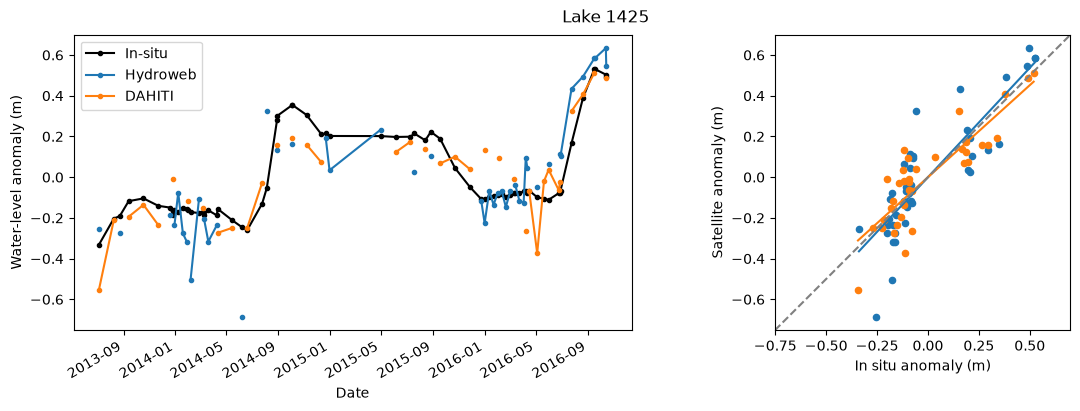

In [21]:
import matplotlib.pyplot as plt

def plot_fit(ax, data, color):
    """Plot a two-column table and its linear fit."""
    x, y = data.iloc[:, 0], data.iloc[:, 1]
    ax.scatter(x, y, color=color, s=20)
    if x.nunique() > 1:
        limits = [x.min(), x.max()]
        ax.plot(limits, np.polyval(np.polyfit(x, y, 1), limits), color=color)

# 1. Prepare data.
lake_id = 1425
lake = matched_data_gdf.loc[matched_data_gdf['lake_id'] == lake_id]
if lake.empty:
    raise ValueError(f'No matched observations for lake {lake_id}.')
water_levels = lake.set_index('date')[[f'water_level_{s}' for s in ['insitu', 'hydroweb', 'dahiti']]].copy()
water_levels.columns = ['In-situ', 'Hydroweb', 'DAHITI']
water_levels.index = pd.to_datetime(water_levels.index)
water_levels = water_levels.sort_index()
insitu_hydroweb = water_levels[['In-situ', 'Hydroweb']].dropna()
insitu_hydroweb -= insitu_hydroweb.mean()  ## 
insitu_dahiti = water_levels[['In-situ', 'DAHITI']].dropna()
insitu_dahiti -= insitu_dahiti.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

# 2. Left plot: center each source on its available dates.
water_levels = water_levels - water_levels.mean()
water_levels.plot(ax=ax1, marker='o', markersize=3, 
                    color=['black', 'tab:blue', 'tab:orange'])

ax1.set(xlabel='Date', ylabel='Water-level anomaly (m)')

# 3. Right plot: use shared-date anomalies; no legend.
plot_fit(ax2, insitu_hydroweb, 'tab:blue')
plot_fit(ax2, insitu_dahiti, 'tab:orange')
# Keep the right panel square with matching axis ranges.
bounds = ax2.get_xlim() + ax2.get_ylim()
limits = (min(bounds), max(bounds))
ax2.axline((0, 0), slope=1, linestyle='--', color='gray')
ax2.set(xlim=limits, ylim=limits, aspect='equal',
        xlabel='In situ anomaly (m)', ylabel='Satellite anomaly (m)')
fig.suptitle(f'Lake {lake_id}')


In [22]:
scores = []
for lake_id, lake in matched_data.groupby('lake_id'):
    for source, column in [('hydroweb', 'water_level_hydroweb'), ('dahiti', 'water_level_dahiti')]:
        paired = lake[['water_level_insitu', column]].dropna()
        if len(paired) < 5:
            continue
        centered = paired - paired.mean()
        scores.append({
            'lake_id': lake_id, 'source': source, 'n': len(paired),
            'r': paired['water_level_insitu'].corr(paired[column]),
            'RMSE_zm': np.sqrt(((centered['water_level_insitu'] - centered[column]) ** 2).mean()),
        })
metrics = pd.DataFrame(scores, columns=['lake_id', 'source', 'n', 'r', 'RMSE_zm'])
metrics


,lake_id,source,n,r,RMSE_zm
0,1425,hydroweb,44,0.857766,0.148238
1,1425,dahiti,36,0.862512,0.117745
